# Level 3a Early ConvNeXt_Tiny

**Task**: Binary classification - Cascade Level 3a Early Stages (I and II)
**Model**: ConvNeXt_Tiny
**Platform**: Kaggle (GPU T$)
**Hyperparameters**: Pre-filled from Optuna search

---

## Notebook Structure

1. Environment setup.
2. Configuration - all hyperparameters in one place.
3. Dataset & stratified split (70 / 20 / 10).
4. Class distribution analysis.
5. Custom heads, model builder, optimizers, schedulers, freeze helpers & early stopping.
6. Training loop.
7. Training curve analysis.
8. Evaluation - confusion matrix (raw + normalised).
9. Evaluation - full classification report.
10. Evaluation - ROC curve & AUC with Youden threshold.
11. Evaluation - threshold sensitivity analysis.
12. Model export & summary.

## 1. Environment Setup

In [1]:
!pip install -q accelerate albumentations timm adamp lion-pytorch

  Preparing metadata (setup.py) ... done


In [2]:
import os, gc, random,torch, timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import torch.nn as nn
import torch.nn.functional as F
import albumentations as A
import torch.optim as optim
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models
from albumentations.pytorch import ToTensorV2
from accelerate import Accelerator
from adamp import AdamP
from lion_pytorch import Lion
from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score,
)

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

#  Reproducibility 
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.benchmark     = False
torch.backends.cudnn.deterministic = True
# TF32 on Ampere+ GPUs (safe speed-up for convnets)
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
print("Environment ready.")
print(f"PyTorch {torch.__version__} | timm {timm.__version__} | CUDA: {torch.cuda.is_available()}")

Environment ready.
PyTorch 2.9.0+cu126 | timm 1.0.24 | CUDA: True


/usr/local/lib/python3.12/dist-packages/torch/backends/__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  self.setter(val)


## 2. Configuration


In [3]:
# Paths
ROOT_DIR = "/kaggle/input/datasets/cezarytubacki/psd-early/PSD - early"
OUTPUT_DIR = "/kaggle/working"

# Split
TRAIN_RATIO = 0.70
VAL_RATIO = 0.20
TEST_RATIO = 0.10

# Optuna best params 
MODEL_NAME = "ConvNeXt_Tiny"
HEAD_TYPE = "linear"  
DROPOUT = 0.160100050336993
LR = 0.00012905300084668555
WEIGHT_DECAY = 1.056908399247601e-05
BATCH_SIZE = 16
GRADIENT_ACCUMULATION = 1
NUM_EPOCHS  = 50                  # raised ceiling — early stopping will cut this short
OPTIMIZER_NAME = "Lion"             
SCHEDULER_NAME  = "CosineAnnealingLR" 
UNFREEZE_EPOCH_STAGE1 = 1                  
UNFREEZE_EPOCH_STAGE2 = 3                 
NUM_BLOCKS_TO_UNFREEZE = 0  

# Margin-head parameters (only used for cosface_head / arcface_head)
SCALE  = 30.0
MARGIN = 0.35  # CosFace default; use 0.5 for ArcFace

# Attention heads: number of heads (must divide evenly into in_features)
ATTN_NUM_HEADS = 8

#  Early stopping 
ES_PATIENCE = 10
ES_DELTA = 1e-4

# Scheduler params

_SCHED_MAP = {
    "CosineAnnealingLR": {"T_max": NUM_EPOCHS},
    "ReduceLROnPlateau": {"factor": 0.3, "patience": 3, "min_lr": 1e-6},
    "StepLR":            {"step_size": 10, "gamma": 0.3},
    "ExponentialLR":     {"gamma": 0.95},
}
SCHEDULER_PARAMS = _SCHED_MAP[SCHEDULER_NAME]

IS_MARGIN_HEAD = HEAD_TYPE in ("cosface_head", "arcface_head")
# Margin heads output [B, 2] → CrossEntropyLoss + long labels
# Standard heads output [B, 1] → BCEWithLogitsLoss + float labels
NUM_CLASSES = 2 if IS_MARGIN_HEAD else 1

# Binary classification threshold
# Updated automatically after ROC analysis (Youden's J)
BINARY_THRESHOLD = 0.5

print(f"Model : {MODEL_NAME}")
print(f"Head : {HEAD_TYPE} (margin_head={IS_MARGIN_HEAD}, num_classes={NUM_CLASSES}) | Dropout: {DROPOUT:.4f}")
print(f"Optimizer : {OPTIMIZER_NAME} | LR: {LR:.2e} | WD: {WEIGHT_DECAY:.2e}")
print(f"Batch size : {BATCH_SIZE} | Max epochs: {NUM_EPOCHS}")
print(f"Scheduler : {SCHEDULER_NAME} | params: {SCHEDULER_PARAMS}")
print(f"Early stopping: patience={ES_PATIENCE}, delta={ES_DELTA}")
print(f"Unfreeze : stage1 @ ep {UNFREEZE_EPOCH_STAGE1} ({NUM_BLOCKS_TO_UNFREEZE} blocks),",
      f"stage2 @ ep {UNFREEZE_EPOCH_STAGE2} (full)")

Model : ConvNeXt_Tiny
Head : linear (margin_head=False, num_classes=1) | Dropout: 0.1601
Optimizer : Lion | LR: 1.29e-04 | WD: 1.06e-05
Batch size : 16 | Max epochs: 50
Scheduler : CosineAnnealingLR | params: {'T_max': 50}
Early stopping: patience=10, delta=0.0001
Unfreeze : stage1 @ ep 1 (0 blocks), stage2 @ ep 3 (full)


## 3. Dataset Classes & Stratified Split

Stratified 70 / 20 / 10. 

In [4]:
class PressureSoreDataset(Dataset):
    """Loads images from class subfolders. Returns raw PIL Images."""
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.image_paths = []
        self.labels = []
        self.class_to_idx = {}
        self.idx_to_class = []

        for i, name in enumerate(sorted(os.listdir(root_dir))):
            if os.path.isdir(os.path.join(root_dir, name)):
                self.class_to_idx[name] = i
                self.idx_to_class.append(name)

        for name in sorted(os.listdir(root_dir)):
            label_dir = os.path.join(root_dir, name)
            if not os.path.isdir(label_dir):
                continue
            for fname in os.listdir(label_dir):
                fpath = os.path.join(label_dir, fname)
                if fpath.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                    self.image_paths.append(fpath)
                    self.labels.append(self.class_to_idx[name])

        print(f"Found {len(self.image_paths)} images in {len(self.class_to_idx)} classes.")
        print(f"Class mapping: {self.class_to_idx}")

    def __len__(self):  return len(self.image_paths)
    def __getitem__(self, idx):
        return Image.open(self.image_paths[idx]).convert("RGB"), self.labels[idx]


class TransformedDataset(Dataset):
    """Wraps a Subset and applies an Albumentations transform."""
    def __init__(self, base_dataset, transform):
        self.base_dataset = base_dataset
        self.transform = transform

    def __len__(self):  return len(self.base_dataset)
    def __getitem__(self, idx):
        image, label = self.base_dataset[idx]
        if self.transform:
            if isinstance(self.transform, A.core.composition.BaseCompose):
                image = self.transform(image=np.array(image))["image"]
            else:
                image = self.transform(image)
        return image, label


# Load 
full_dataset = PressureSoreDataset(ROOT_DIR)
all_labels = full_dataset.labels
class_names = full_dataset.idx_to_class
n_classes = len(class_names)

assert n_classes == 2, (
    f"Expected 2 classes (Stage I, Stage II) but found {n_classes}: {class_names}. "
    "Check ROOT_DIR points to the correct Early subset."
)

# Stratified split 
indices = list(range(len(full_dataset)))
train_idx, temp_idx = train_test_split(
    indices, test_size=(VAL_RATIO + TEST_RATIO),
    stratify=all_labels, random_state=SEED
)
temp_labels = [all_labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    stratify=temp_labels, random_state=SEED
)

print(f"\nStratified split (seed={SEED}):")
for name, idx_list in [("Train", train_idx), ("Val", val_idx), ("Test", test_idx)]:
    split_lbl = [all_labels[i] for i in idx_list]
    counts = {c: split_lbl.count(v) for c, v in full_dataset.class_to_idx.items()}
    print(f"{name:5s}: {len(idx_list):4d} images | {counts}")

Found 620 images in 2 classes.
Class mapping: {'stage I': 0, 'stage II': 1}

Stratified split (seed=42):
Train:  433 images | {'stage I': 216, 'stage II': 217}
Val  :  124 images | {'stage I': 62, 'stage II': 62}
Test :   63 images | {'stage I': 32, 'stage II': 31}


## 4. Class Distribution Analysis

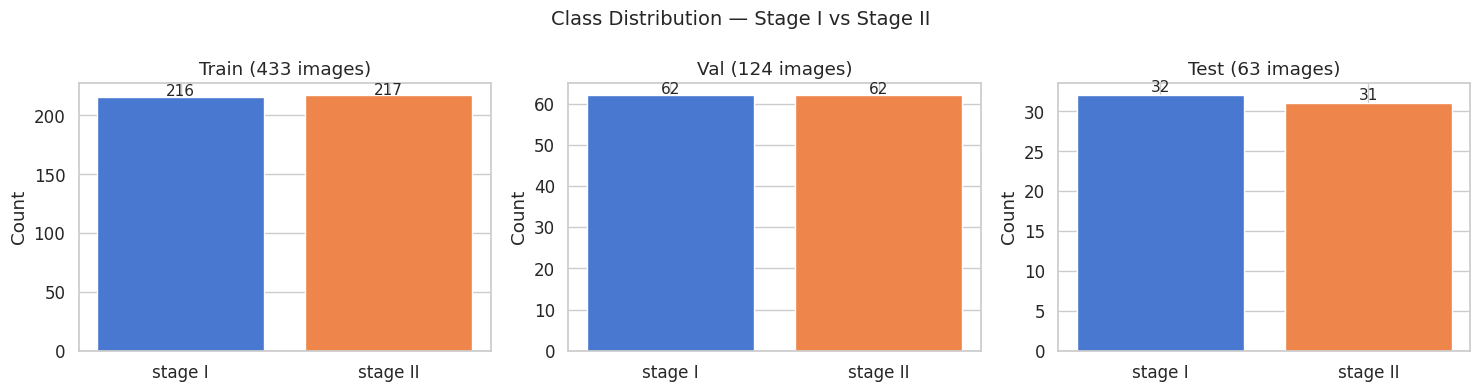

Train imbalance ratio: 1.00

Stage I vs Stage II is typically the hardest binary split in the cascade.
Stage I shows non-blanchable erythema; Stage II has partial thickness skin loss.
Subtle visual differences mean higher imbalance sensitivity.


In [5]:
split_data = {
    "Train": [all_labels[i] for i in train_idx],
    "Val": [all_labels[i] for i in val_idx],
    "Test": [all_labels[i] for i in test_idx],
}
# Stage I vs Stage II is often imbalanced — flag clearly
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (split_name, lbls) in zip(axes, split_data.items()):
    counts = [lbls.count(v) for v in range(n_classes)]
    bars = ax.bar(class_names, counts, color=sns.color_palette("muted", n_classes))
    ax.set_title(f"{split_name} ({len(lbls)} images)")
    ax.set_ylabel("Count")
    for bar, v in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5, str(v), ha="center", fontsize=11)
plt.suptitle("Class Distribution — Stage I vs Stage II", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

train_counts = [split_data["Train"].count(v) for v in range(n_classes)]
ratio = max(train_counts) / (min(train_counts) or 1)
flag  = "⚠️  consider class weights or oversampling" if ratio > 2 else ""
print(f"Train imbalance ratio: {ratio:.2f}{flag}")
print()
print("Stage I vs Stage II is typically the hardest binary split in the cascade.")
print("Stage I shows non-blanchable erythema; Stage II has partial thickness skin loss.")
print("Subtle visual differences mean higher imbalance sensitivity.")

## 5. Custom Heads, Model Builder, Optimizer, Scheduler, Freeze Helpers & Early Stopping


In [6]:
# Classification Heads

class LinearHead(nn.Module):
    """GAP (for CNNs) → Dropout → Linear."""
    def __init__(self, in_features, num_classes=1, dropout=0.3):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(in_features, num_classes)

    def forward(self, x, labels=None):
        if x.dim() == 4:
            x = self.pool(x).squeeze(-1).squeeze(-1)
        return self.fc(self.dropout(x))


class MLPHead(nn.Module):
    """GAP → Dropout → FC → BN → ReLU → Dropout → FC."""
    def __init__(self, in_features, num_classes=1, hidden_dim=512, dropout=0.3):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.mlp = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, hidden_dim),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x, labels=None):
        if x.dim() == 4:
            x = self.pool(x).squeeze(-1).squeeze(-1)
        return self.mlp(x)


class MultiStageHead(nn.Module):
    """GAP → Dropout → FC → LN → ReLU → FC."""
    
    def __init__(self, in_features, num_classes=1, dropout=0.5):
        super().__init__()

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)

        hidden = in_features // 2

        self.fc1 = nn.Linear(in_features, hidden)
        self.norm = nn.LayerNorm(hidden)
        self.relu = nn.ReLU(inplace=True)

        self.fc2 = nn.Linear(hidden, num_classes)

    def forward(self, x, labels=None):

        if x.dim() == 4:
            x = self.pool(x).squeeze(-1).squeeze(-1)

        x = self.dropout(x)
        x = self.fc1(x)
        x = self.norm(x)
        x = self.relu(x)

        return self.fc2(x)


class SpatialAttentionHead(nn.Module):
    def __init__(self, in_features, num_classes=1, dropout=0.4, num_heads=None):
        super().__init__()

        self.fc = nn.Sequential(
            nn.LayerNorm(in_features),
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x, labels=None):
        return self.fc(x)


class AttentionHead(nn.Module):
    """MHA + LayerNorm pool. Handles [B,C,H,W] and [B,D]."""
    def __init__(self, in_features, num_classes=1, dropout=0.3):
        super().__init__()

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc1 = nn.Linear(in_features, 512)
        self.norm = nn.LayerNorm(512)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x, labels=None):
        if x.dim() == 4:
            x = self.pool(x).squeeze(-1).squeeze(-1)

        x = self.fc1(x)
        x = self.norm(x)
        x = self.relu(x)
        x = self.dropout(x)

        return self.fc2(x)

class CosFaceHead(nn.Module):
    """
    CosFace (additive cosine margin) head.
    Output: scaled cosine logits [B, num_classes]. Use with CrossEntropyLoss.
    Training  → forward(x, labels)  applies margin to ground-truth class.
    Inference → forward(x)  returns raw scaled logits.
    """
    def __init__(self, in_features, num_classes=2, scale=30.0, margin=0.35):
        super().__init__()
        self.scale = scale
        self.margin = margin
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, in_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, x, labels=None):
        if x.dim() == 4:
            x = x.mean(dim=[2, 3])
        x = F.normalize(x, dim=1)
        w = F.normalize(self.weight, dim=1)
        cosine = F.linear(x, w)
        if labels is not None:
            one_hot = torch.zeros_like(cosine)
            one_hot.scatter_(1, labels.long().view(-1, 1), 1.0)
            cosine = cosine - one_hot * self.margin
        return cosine * self.scale


class ArcFaceHead(nn.Module):
    """
    ArcFace (additive angular margin) head.
    Output: scaled cosine logits [B, num_classes]. Use with CrossEntropyLoss.
    Training  → forward(x, labels)  adds angular margin before scaling.
    Inference → forward(x) returns raw scaled logits.
    """
    def __init__(self, in_features, num_classes=2, scale=30.0, margin=0.5):
        super().__init__()
        self.scale = scale
        self.margin = margin
        self.weight = nn.Parameter(torch.randn(num_classes, in_features))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, x, labels=None):
        if x.dim() == 4:
            x = x.mean(dim=[2, 3])
        x = F.normalize(x, dim=1)
        w = F.normalize(self.weight, dim=1)
        logits = F.linear(x, w)
        if labels is None:
            return logits * self.scale
        theta = torch.acos(torch.clamp(logits, -1.0 + 1e-7, 1.0 - 1e-7))
        target_logits = torch.cos(theta + self.margin)
        one_hot = torch.zeros_like(logits)
        one_hot.scatter_(1, labels.long().view(-1, 1), 1.0)
        logits = logits * (1 - one_hot) + target_logits * one_hot
        return logits * self.scale


print("All heads defined.")

All heads defined.


In [7]:

# Model zoo

TIMM_MODELS = {
    "convnextv2_tiny" : "convnextv2_tiny.fcmae_ft_in22k_in1k",
    "convnextv2_base" : "convnextv2_base.fcmae_ft_in22k_in1k",
    "convnextv2_large" : "convnextv2_large.fcmae_ft_in22k_in1k",
    "vit_large_224" : "vit_large_patch32_224.orig_in21k",
    "deit3_large_224" : "deit3_large_patch16_224.fb_in22k_ft_in1k",
    "eva02_small_224" : "eva02_small_patch14_224.mim_in22k",
    "beit_large_224" : "beit_large_patch16_224",
    "coatnet_7" : "coatnet_rmlp_2_rw_384.sw_in12k_ft_in1k",
    "efficientnetv2_l" : "tf_efficientnetv2_l.in21k_ft_in1k",
    "nfnet_l0" : "eca_nfnet_l0",
}

# Block container name for partial unfreezing (stage 1)
MODEL_LAYERS_MAP = {
    "convnextv2_tiny.fcmae_ft_in22k_in1k" : "stages",
    "convnextv2_base.fcmae_ft_in22k_in1k" : "stages",
    "convnextv2_large.fcmae_ft_in22k_in1k" : "stages",
    "vit_large_patch32_224.orig_in21k" : "blocks",
    "deit3_large_patch16_224.fb_in22k_ft_in1k" : "blocks",
    "eva02_small_patch14_224.mim_in22k" : "blocks",
    "beit_large_patch16_224" : "blocks",
    "coatnet_rmlp_2_rw_384.sw_in12k_ft_in1k" : "stages",
    "tf_efficientnetv2_l.in21k_ft_in1k" : "blocks",
    "eca_nfnet_l0" : "stages",
}


def build_model(
    model_name: str,
    num_classes: int = 1,
    dropout: float = 0.3,
    head_type: str = "linear",
    scale: float = 30.0,
    margin: float = 0.35,
    num_heads: int = 8,
):
    """
    Builds a backbone (timm or torchvision) and attaches the chosen head.
    For timm: backbone loaded with num_classes=0, head attached as model.head.
    For torchvision: final layer replaced as before.
    CosFace / ArcFace: pass num_classes=2 for binary.
    """
    if isinstance(head_type, tuple):
        head_type = head_type[0]

    TV_WEIGHTS = {
        "EfficientNet_B0" : models.EfficientNet_B0_Weights.IMAGENET1K_V1,
        "EfficientNet_B1" : models.EfficientNet_B1_Weights.IMAGENET1K_V2,
        "EfficientNet_B4" : models.EfficientNet_B4_Weights.IMAGENET1K_V1,
        "EfficientNet_B7" : models.EfficientNet_B7_Weights.IMAGENET1K_V1,
        "EfficientNet_V2_L" : models.EfficientNet_V2_L_Weights.IMAGENET1K_V1,
        "ViT_B_16" : models.ViT_B_16_Weights.IMAGENET1K_V1,
        "MaxVit_T" : models.MaxVit_T_Weights.IMAGENET1K_V1,
        "Wide_ResNet50_2" : models.Wide_ResNet50_2_Weights.IMAGENET1K_V2,
        "ResNet50" : models.ResNet50_Weights.IMAGENET1K_V2,
        "ResNet152" : models.ResNet152_Weights.IMAGENET1K_V2,
        "Swin_V2_S" : models.Swin_V2_S_Weights.IMAGENET1K_V1,
        "Swin_V2_T" : models.Swin_V2_T_Weights.IMAGENET1K_V1,
        "ConvNeXt_Tiny" : models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1,
        "ConvNeXt_Base" : models.ConvNeXt_Base_Weights.IMAGENET1K_V1,
        "ConvNeXt_Large" : models.ConvNeXt_Large_Weights.IMAGENET1K_V1,
        "RegNet_Y_8GF" : models.RegNet_Y_8GF_Weights.IMAGENET1K_V2,
        "RegNet_Y_16GF" : models.RegNet_Y_16GF_Weights.IMAGENET1K_SWAG_E2E_V1,
    }
    TV_FN = {
        "EfficientNet_B0" :   models.efficientnet_b0,
        "EfficientNet_B1" :   models.efficientnet_b1,
        "EfficientNet_B4" :   models.efficientnet_b4,
        "EfficientNet_B7" :   models.efficientnet_b7,
        "EfficientNet_V2_L" : models.efficientnet_v2_l,
        "ViT_B_16" : models.vit_b_16,
        "MaxVit_T" : models.maxvit_t,
        "Wide_ResNet50_2" : models.wide_resnet50_2,
        "ResNet50" :  models.resnet50,
        "ResNet152" : models.resnet152,
        "Swin_V2_S" : models.swin_v2_s,
        "Swin_V2_T" : models.swin_v2_t,
        "ConvNeXt_Tiny" : models.convnext_tiny,
        "ConvNeXt_Base" : models.convnext_base,
        "ConvNeXt_Large" : models.convnext_large,
        "RegNet_Y_8GF" : models.regnet_y_8gf,
        "RegNet_Y_16GF" : models.regnet_y_16gf,
    }
    HEADS = {
        "linear" : LinearHead,
        "mlp" : MLPHead,
        "multi_stage_head" : MultiStageHead,
        "spatial_head" : SpatialAttentionHead,
        "attention_head" : AttentionHead,
        "cosface_head" : CosFaceHead,
        "arcface_head" : ArcFaceHead,
    }

    # Load backbone
    is_timm = model_name in TIMM_MODELS
    if is_timm:
        full_name = TIMM_MODELS[model_name]
        backbone = timm.create_model(full_name, pretrained=True, num_classes=0)
        in_features = backbone.num_features
        if hasattr(backbone, "set_grad_checkpointing"):
            backbone.set_grad_checkpointing(True)
            print(f"Gradient checkpointing enabled for {model_name}")
    elif model_name in TV_WEIGHTS:
        backbone = TV_FN[model_name](weights=TV_WEIGHTS[model_name])
        if model_name.startswith("ViT"):
            in_features = backbone.heads.head.in_features
        elif model_name.startswith("MaxVit"):
            in_features = backbone.classifier[5].in_features
        elif model_name.startswith("Conv"):
            in_features = backbone.classifier[2].in_features
        elif model_name.startswith("Swin"):
            in_features = backbone.head.in_features
        elif model_name.startswith("RegNet"):
            in_features = backbone.fc.in_features
        elif hasattr(backbone, "fc"):
            in_features = backbone.fc.in_features
        else:
            in_features = backbone.classifier[1].in_features
    else:
        raise ValueError(f"'{model_name}' not found in timm or torchvision zoo.")

    # Build head 
    if head_type not in HEADS:
        raise ValueError(f"Unknown head_type '{head_type}'. Choose from: {list(HEADS)}")
    head_cls = HEADS[head_type]
    if head_type in ("cosface_head", "arcface_head"):
        head = head_cls(in_features=in_features, num_classes=num_classes,
                        scale=scale, margin=margin)
    elif head_type == "spatial_head":
        head = head_cls(in_features=in_features, num_classes=num_classes,
                        dropout=dropout, num_heads=num_heads)
    elif head_type == "attention_head":
        head = head_cls(in_features=in_features, num_classes=num_classes,
                        num_heads=num_heads, dropout=dropout)
    else:
        head = head_cls(in_features=in_features, num_classes=num_classes, dropout=dropout)

    #  Attach head 
    if is_timm:
        backbone.head = head
    elif model_name.startswith("ViT"):
        backbone.heads.head = head
    elif model_name.startswith("MaxVit"):
        backbone.classifier[5] = head
    elif model_name.startswith("Conv"):
        backbone.classifier[2] = head
    elif model_name.startswith("Swin"):
        backbone.head = head
    elif model_name.startswith("RegNet"):
        backbone.fc = head
    elif hasattr(backbone, "fc"):
        backbone.fc = head
    else:
        backbone.classifier = head

    print(f"Built '{model_name}' | in_features={in_features} | head='{head_type}' | num_classes={num_classes}")
    return backbone


print("build_model defined.")

build_model defined.


In [8]:
# Optimizer & Scheduler

def build_optimizer(name, parameters, params=None):
    p = dict(params or {})
    if name == "AdamW" : return optim.AdamW(parameters, **p)
    if name == "RAdam" : return optim.RAdam(parameters, **p)
    if name == "AdamP" : return AdamP(parameters, **p)
    if name == "Lion" : return Lion(parameters, **p)
    if name == "SGD" : return optim.SGD(parameters, **p)
    raise ValueError(f"Unknown optimizer: {name}")


def build_scheduler(name, optimizer, num_epochs=None, params=None):
    p = dict(params or {})
    if name == "CosineAnnealingLR":
        if "T_max" not in p and num_epochs: p["T_max"] = num_epochs
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, **p)
    if name == "ReduceLROnPlateau":
        return optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", **p)
    if name == "StepLR":
        return optim.lr_scheduler.StepLR(optimizer, **p)
    if name == "ExponentialLR":
        return optim.lr_scheduler.ExponentialLR(optimizer, **p)
    raise ValueError(f"Unknown scheduler: {name}")



# Freeze / Unfreeze helpers

def set_requires_grad(model, flag):
    for p in model.parameters(): p.requires_grad = flag


def freeze_backbone_except_head(model):
    """
    Freeze everything, then unfreeze any module whose name contains
    'head', 'fc', or 'classifier'. Works for timm and torchvision
    without model-specific branching.
    """
    set_requires_grad(model, False)
    head_names = []
    for name, module in model.named_modules():
        if any(k in name for k in ("head", "fc", "classifier")):
            set_requires_grad(module, True)
            head_names.append(name)
    if head_names:
        print(f"Backbone frozen. Trainable head modules: {head_names}")
    else:
        print("⚠️ No head module found — check model architecture.")
    n_trainable = sum(p.requires_grad for p in model.parameters())
    print(f"{n_trainable} trainable parameters.")


def unfreeze_stage(model, model_name: str, stage: int, num_blocks: int = 1):
    """
    Stage 2 → full model trainable.
    Stage 1 → unfreeze last `num_blocks` from the block container
              in MODEL_LAYERS_MAP, then keep head trainable.
    """
    if stage == 2:
        print("  Unfreezing full backbone.")
        set_requires_grad(model, True)
        return

    full_name = TIMM_MODELS.get(model_name, model_name).lower()
    block_attr = MODEL_LAYERS_MAP.get(full_name)

    set_requires_grad(model, False)

    if block_attr is None:
        for attr in ("features", "layer4", "blocks"):
            container = getattr(model, attr, None)
            if container is not None:
                blocks = list(container.children())
                for blk in blocks[-num_blocks:]:
                    set_requires_grad(blk, True)
                print(f"  Unfroze last {num_blocks} from '{attr}' (torchvision fallback).")
                break
    else:
        container = getattr(model, block_attr, None)
        if container is None:
            print(f"⚠️  Attribute '{block_attr}' not found on model.")
        else:
            blocks = list(container.children())
            for blk in blocks[-num_blocks:]:
                set_requires_grad(blk, True)
            print(f"Unfroze last {num_blocks} block(s) from '{block_attr}'.")

    # Head always stays trainable
    for name, module in model.named_modules():
        if any(k in name for k in ("head", "fc", "classifier")):
            set_requires_grad(module, True)

    n = sum(p.requires_grad for p in model.parameters())
    print(f"Trainable parameters after stage-1 unfreeze: {n}")



# Early Stopping

class EarlyStopping:
    """
    Monitors val_loss. Saves checkpoint when loss improves by > delta.
    Stops when no improvement for `patience` epochs.
    Counter resets on unfreeze events.
    """
    def __init__(self, patience=10, delta=1e-4, path="checkpoint.pth", verbose=True):
        self.patience  = patience
        self.delta = delta
        self.path = path
        self.verbose = verbose
        self.counter = 0
        self.best_loss = float("inf")
        self.early_stop = False

    def __call__(self, val_loss, model):
        if val_loss < (self.best_loss - self.delta):
            if self.verbose:
                print(f"✅ val_loss {self.best_loss:.4f} → {val_loss:.4f}  (checkpoint saved)")
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.path)
            return True
        else:
            self.counter += 1
            if self.verbose:
                print(f"No improvement {self.counter}/{self.patience}  (best={self.best_loss:.4f})")
            if self.counter >= self.patience:
                self.early_stop = True
                print(" 🛑 Early stopping triggered.")
            return False


print("All helpers defined.")

All helpers defined.


## 6. Training Loop

In [9]:
# Resolve image size and normalisation from timm config 
IMG_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

if MODEL_NAME in TIMM_MODELS:
    full_timm_name = TIMM_MODELS[MODEL_NAME]
    try:
        cfg = timm.get_pretrained_cfg(full_timm_name)
        IMG_SIZE = cfg.input_size[-1]
        MEAN = list(cfg.mean)
        STD = list(cfg.std)
        print(f"timm config → img_size={IMG_SIZE}, mean={MEAN}, std={STD}")
    except Exception as e:
        print(f"Could not fetch timm config ({e}). Using ImageNet defaults.")
else:
    print(f"Torchvision model — using ImageNet defaults: img_size={IMG_SIZE}")

# Transforms 
train_transforms = A.Compose([
    A.Resize(IMG_SIZE + 32, IMG_SIZE + 32),
    A.RandomCrop(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.5, border_mode=0),
    A.ColorJitter(brightness=0.1, contrast=0.1, p=0.5),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])
val_test_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

# DataLoaders
num_workers = min(4, os.cpu_count() or 1)
loader_kw = dict(
    batch_size=BATCH_SIZE, pin_memory=torch.cuda.is_available(),
    num_workers=num_workers, persistent_workers=False,
    prefetch_factor=2 if num_workers > 0 else None,
)
train_loader = DataLoader(
    TransformedDataset(Subset(full_dataset, train_idx), train_transforms),
    shuffle=True, **loader_kw
)
val_loader = DataLoader(
    TransformedDataset(Subset(full_dataset, val_idx), val_test_transforms),
    shuffle=False, **loader_kw
)
test_loader = DataLoader(
    TransformedDataset(Subset(full_dataset, test_idx), val_test_transforms),
    shuffle=False, **loader_kw
)
print(f"Batches — train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")

Torchvision model — using ImageNet defaults: img_size=224
Batches — train: 28 | val: 8 | test: 4


In [10]:
# Accelerator, model, loss, early stopping 
accelerator = Accelerator(mixed_precision="fp16")
device = accelerator.device

BEST_WEIGHTS_PATH = (
    f"{OUTPUT_DIR}/best_{MODEL_NAME}_{HEAD_TYPE}_{OPTIMIZER_NAME}_{SCHEDULER_NAME}.pth"
)

model = build_model(
    MODEL_NAME, num_classes=NUM_CLASSES, dropout=DROPOUT,
    head_type=HEAD_TYPE, scale=SCALE, margin=MARGIN, num_heads=ATTN_NUM_HEADS,
)

if IS_MARGIN_HEAD:
    loss_fn = nn.CrossEntropyLoss()
    print("Loss: CrossEntropyLoss  (margin head — labels as long ints)")
else:
    loss_fn = nn.BCEWithLogitsLoss()
    print("Loss: BCEWithLogitsLoss  (standard head — labels as float [B,1])")

early_stopping = EarlyStopping(
    patience=ES_PATIENCE, delta=ES_DELTA,
    path=BEST_WEIGHTS_PATH, verbose=True
)

freeze_backbone_except_head(model)
trainable = filter(lambda p: p.requires_grad, model.parameters())
optimizer = build_optimizer(OPTIMIZER_NAME, trainable, {"lr": LR, "weight_decay": WEIGHT_DECAY})
scheduler = build_scheduler(SCHEDULER_NAME, optimizer, NUM_EPOCHS, SCHEDULER_PARAMS)

model, optimizer, train_loader, val_loader, scheduler = accelerator.prepare(
    model, optimizer, train_loader, val_loader, scheduler
)

history = {"train_loss": [], "val_loss": [], "val_acc": []}
print(f"\nTraining on {device}")

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 168MB/s]  


Built 'ConvNeXt_Tiny' | in_features=768 | head='linear' | num_classes=1
Loss: BCEWithLogitsLoss  (standard head — labels as float [B,1])
Backbone frozen. Trainable head modules: ['classifier', 'classifier.0', 'classifier.1', 'classifier.2', 'classifier.2.pool', 'classifier.2.dropout', 'classifier.2.fc']
4 trainable parameters.

Training on cuda


In [11]:
# Training loop 
for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("─" * 52)

    # Gradual unfreezing 
    unwrapped = accelerator.unwrap_model(model)
    for stage, trigger in [(1, UNFREEZE_EPOCH_STAGE1), (2, UNFREEZE_EPOCH_STAGE2)]:
        if trigger is not None and epoch + 1 == trigger:
            unfreeze_stage(unwrapped, MODEL_NAME, stage=stage, num_blocks=NUM_BLOCKS_TO_UNFREEZE)
            trainable = filter(lambda p: p.requires_grad, unwrapped.parameters())
            optimizer = build_optimizer(OPTIMIZER_NAME, trainable, {"lr": LR, "weight_decay": WEIGHT_DECAY})
            scheduler = build_scheduler(SCHEDULER_NAME, optimizer, NUM_EPOCHS, SCHEDULER_PARAMS)
            model, optimizer, train_loader, val_loader, scheduler = accelerator.prepare(
                unwrapped, optimizer, train_loader, val_loader, scheduler
            )
            early_stopping.counter = 0
            print(f"  Early stopping counter reset after stage-{stage} unfreeze.")

    # Train phase
    model.train()
    train_loss = 0.0
    for step, (inputs, labels) in enumerate(tqdm(train_loader, desc="  Train", leave=False)):
        inputs = inputs.to(device)
        with accelerator.accumulate(model):
            optimizer.zero_grad()
            if IS_MARGIN_HEAD:
                labels_dev = labels.long().to(device)
                logits = model(inputs, labels_dev)
                loss = loss_fn(logits, labels_dev)
            else:
                labels_dev = labels.float().unsqueeze(1).to(device)
                logits = model(inputs)
                loss = loss_fn(logits, labels_dev)
            accelerator.backward(loss)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        train_loss += loss.item()
    avg_train_loss = train_loss / len(train_loader)

    #  Validation phase 
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc="  Val  ", leave=False):
            inputs = inputs.to(device)
            if IS_MARGIN_HEAD:
                labels_dev = labels.long().to(device)
                logits = model(inputs)
                loss = loss_fn(logits, labels_dev)
                preds = logits.argmax(dim=1)
                val_correct += (preds == labels_dev).sum().item()
            else:
                labels_dev = labels.float().unsqueeze(1).to(device)
                logits = model(inputs)
                loss = loss_fn(logits, labels_dev)
                preds = (torch.sigmoid(logits) >= BINARY_THRESHOLD).float()
                val_correct += (preds == labels_dev).sum().item()
            val_loss  += loss.item()
            val_total += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total

    if SCHEDULER_NAME == "ReduceLROnPlateau":
        scheduler.step(avg_val_loss)
    else:
        scheduler.step()

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["val_acc"].append(val_acc)

    print(f"train_loss={avg_train_loss:.4f}  val_loss={avg_val_loss:.4f}  val_acc={val_acc:.4f}")

    early_stopping(avg_val_loss, accelerator.unwrap_model(model))
    if early_stopping.early_stop:
        print(f"\nStopped at epoch {epoch+1}. Best val_loss: {early_stopping.best_loss:.4f}")
        break

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

# ── Restore best weights ──────────────────────────────────────
print("\nRestoring best checkpoint…")
accelerator.unwrap_model(model).load_state_dict(
    torch.load(BEST_WEIGHTS_PATH, map_location=device)
)
print(f"Epochs run: {len(history['train_loss'])} / {NUM_EPOCHS}")


Epoch 1/50
────────────────────────────────────────────────────
  Unfroze last 0 from 'features' (torchvision fallback).
Trainable parameters after stage-1 unfreeze: 182
  Early stopping counter reset after stage-1 unfreeze.


  Train:   0%|          | 0/28 [00:00<?, ?it/s]

  Val  :   0%|          | 0/8 [00:00<?, ?it/s]

train_loss=0.5141  val_loss=0.4162  val_acc=0.8065
✅ val_loss inf → 0.4162  (checkpoint saved)

Epoch 2/50
────────────────────────────────────────────────────


  Train:   0%|          | 0/28 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/8 [00:00<?, ?it/s]

train_loss=0.2257  val_loss=0.3064  val_acc=0.8952
No improvement 9/10  (best=0.2296)

Epoch 13/50
────────────────────────────────────────────────────


  Train:   0%|          | 0/28 [00:00<?, ?it/s]

  Val  :   0%|          | 0/8 [00:00<?, ?it/s]

train_loss=0.2255  val_loss=0.3727  val_acc=0.8952
No improvement 10/10  (best=0.2296)
 🛑 Early stopping triggered.

Stopped at epoch 13. Best val_loss: 0.2296

Restoring best checkpoint…
Epochs run: 13 / 50


## 7. Training Curve Analysis

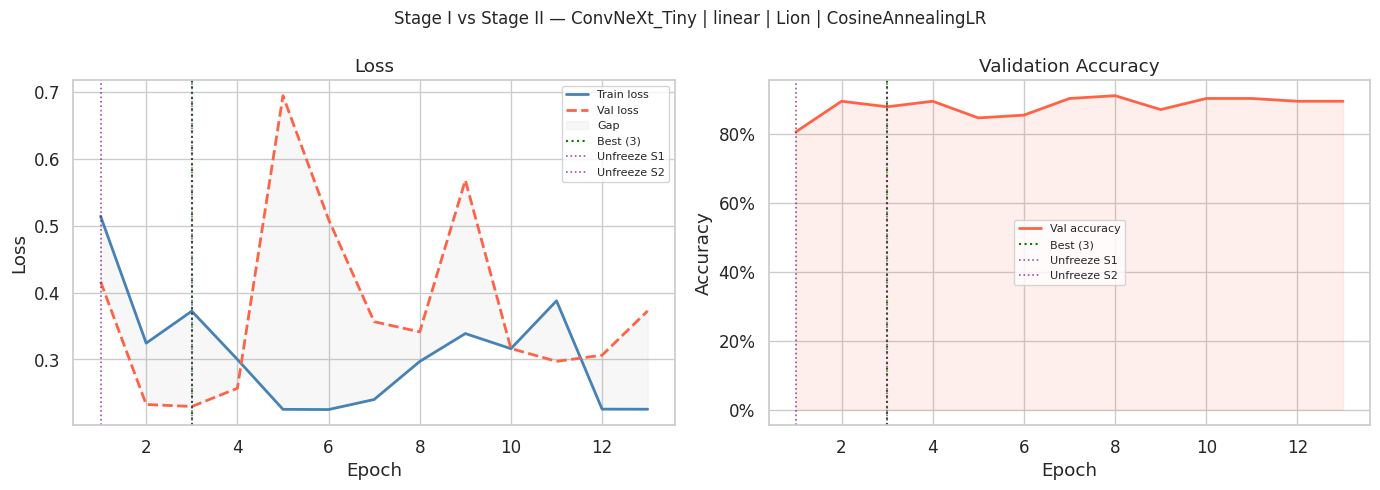

Best epoch: 3 | best val_loss: 0.2296


In [12]:
epochs_x = list(range(1, len(history["train_loss"]) + 1))
best_epoch = int(np.argmin(history["val_loss"])) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(epochs_x, history["train_loss"], label="Train loss", lw=2, color="steelblue")
ax.plot(epochs_x, history["val_loss"], label="Val loss", lw=2, color="tomato", ls="--")
ax.fill_between(epochs_x, history["train_loss"], history["val_loss"],
                alpha=0.06, color="grey", label="Gap")
ax.axvline(best_epoch, color="green", ls=":", lw=1.5, label=f"Best ({best_epoch})")
for ue, lab in [(UNFREEZE_EPOCH_STAGE1, "S1"), (UNFREEZE_EPOCH_STAGE2, "S2")]:
    if ue and ue <= len(epochs_x):
        ax.axvline(ue, color="purple", ls=":", lw=1.2, alpha=0.7, label=f"Unfreeze {lab}")
ax.set_title("Loss"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(epochs_x, history["val_acc"], lw=2, color="tomato", label="Val accuracy")
ax.fill_between(epochs_x, history["val_acc"], alpha=0.1, color="tomato")
ax.axvline(best_epoch, color="green", ls=":", lw=1.5, label=f"Best ({best_epoch})")
for ue, lab in [(UNFREEZE_EPOCH_STAGE1, "S1"), (UNFREEZE_EPOCH_STAGE2, "S2")]:
    if ue and ue <= len(epochs_x):
        ax.axvline(ue, color="purple", ls=":", lw=1.2, alpha=0.7, label=f"Unfreeze {lab}")
ax.set_title("Validation Accuracy"); ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.legend(fontsize=8)

plt.suptitle(
    f"Stage I vs Stage II — {MODEL_NAME} | {HEAD_TYPE} | {OPTIMIZER_NAME} | {SCHEDULER_NAME}",
    fontsize=12
)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Best epoch: {best_epoch} | best val_loss: {min(history['val_loss']):.4f}")

## 8. Evaluation - Confusion Matrix

Built 'ConvNeXt_Tiny' | in_features=768 | head='linear' | num_classes=1


Evaluating test set:   0%|          | 0/4 [00:00<?, ?it/s]

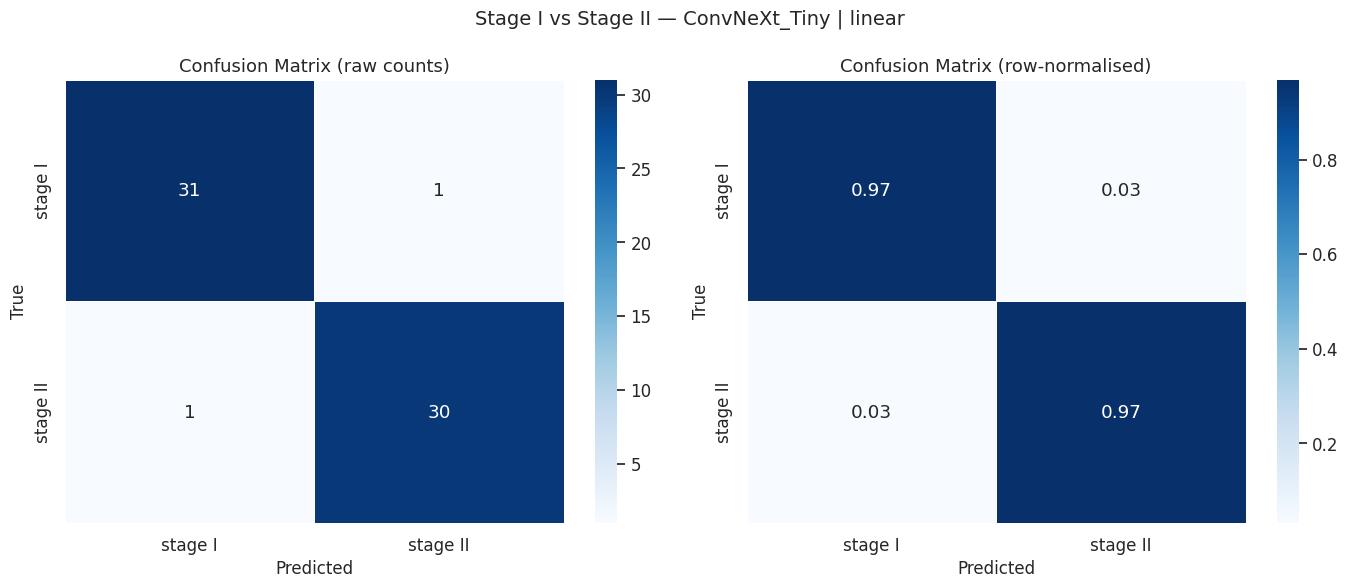

In [13]:
eval_model = build_model(
    MODEL_NAME, num_classes=NUM_CLASSES, dropout=DROPOUT,
    head_type=HEAD_TYPE, scale=SCALE, margin=MARGIN, num_heads=ATTN_NUM_HEADS,
)
eval_model.load_state_dict(torch.load(BEST_WEIGHTS_PATH, map_location="cpu"))
eval_model.eval().to(device)

raw_test_loader = DataLoader(
    TransformedDataset(Subset(full_dataset, test_idx), val_test_transforms),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers,
)

all_labels_test, all_probs_test = [], []
with torch.no_grad():
    for inputs, labels in tqdm(raw_test_loader, desc="Evaluating test set"):
        logits = eval_model(inputs.to(device))   # no labels → inference mode
        if IS_MARGIN_HEAD:
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        else:
            probs = torch.sigmoid(logits.view(-1)).cpu().numpy()
        all_probs_test.extend(probs.tolist())
        all_labels_test.extend(labels.numpy().tolist())

all_probs_test = np.array(all_probs_test)
all_labels_test = np.array(all_labels_test)
all_preds_test = (all_probs_test >= BINARY_THRESHOLD).astype(int)

cm_raw = confusion_matrix(all_labels_test, all_preds_test)
cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cm, title, fmt in zip(
    axes,
    [cm_raw, cm_norm],
    ["Confusion Matrix (raw counts)", "Confusion Matrix (row-normalised)"],
    ["d", ".2f"]
):
    sns.heatmap(cm, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, ax=ax)
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True", fontsize=12)
    ax.set_title(title, fontsize=13)
plt.suptitle(f"Stage I vs Stage II — {MODEL_NAME} | {HEAD_TYPE}", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Evaluation - Full Classification Report

In [14]:
print("=" * 55)
print("CLASSIFICATION REPORT — TEST SET")
print("=" * 55)
print(classification_report(all_labels_test, all_preds_test,
                             target_names=class_names, digits=4))

summary = {
    "Accuracy" : accuracy_score(all_labels_test, all_preds_test),
    "Macro Precision" : precision_score(all_labels_test, all_preds_test, average="macro", zero_division=0),
    "Macro Recall" : recall_score(all_labels_test, all_preds_test, average="macro", zero_division=0),
    "Macro F1" : f1_score(all_labels_test, all_preds_test, average="macro", zero_division=0),
    "Weighted F1" : f1_score(all_labels_test, all_preds_test, average="weighted", zero_division=0),
}
df = pd.DataFrame(summary.items(), columns=["Metric", "Value"])
df["Value"] = df["Value"].map("{:.4f}".format)
display(df.set_index("Metric"))
df.to_csv(f"{OUTPUT_DIR}/metrics_summary.csv", index=False)

CLASSIFICATION REPORT — TEST SET
              precision    recall  f1-score   support

     stage I     0.9688    0.9688    0.9688        32
    stage II     0.9677    0.9677    0.9677        31

    accuracy                         0.9683        63
   macro avg     0.9682    0.9682    0.9682        63
weighted avg     0.9683    0.9683    0.9683        63



,Value
Metric,
Accuracy,0.9683
Macro Precision,0.9682
Macro Recall,0.9682
Macro F1,0.9682
Weighted F1,0.9683


## 10. Evaluation - ROC Curve & AUC with Youden Threshold

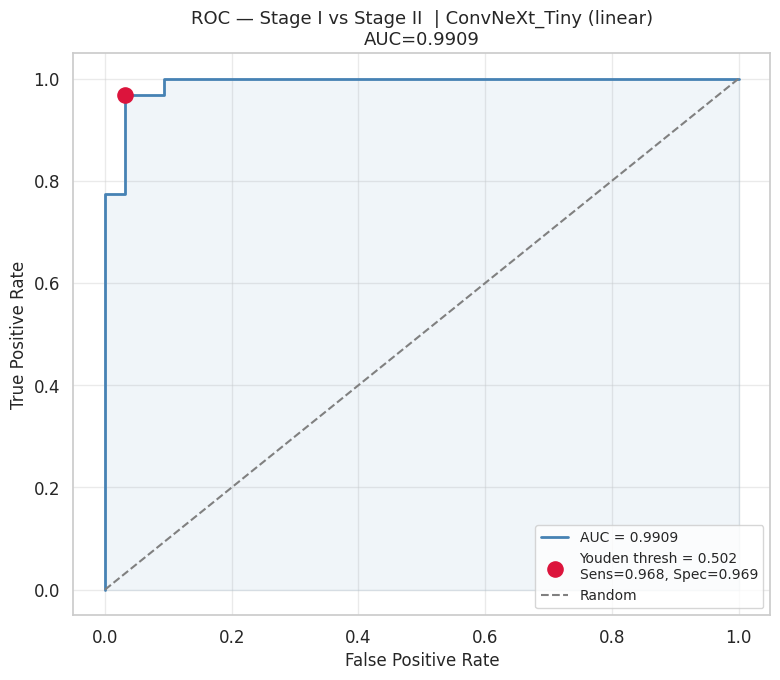

AUC-ROC : 0.9909
Youden threshold: 0.5025

At Youden threshold:
Accuracy : 0.9683
Macro F1 : 0.9682
Recall : 0.9677
Precision : 0.9677


In [15]:
# Positive class = Stage II (higher numerical stage)
pos_name = next(
    (c for c in class_names if "ii" in c.lower() or "2" in c),
    class_names[1]
)
pos_class_idx = full_dataset.class_to_idx[pos_name]
pos_probs = all_probs_test if pos_class_idx == 1 else (1 - all_probs_test)
binary_labels = (all_labels_test == pos_class_idx).astype(int)

fpr, tpr, thresholds = roc_curve(binary_labels, pos_probs)
auc_val = roc_auc_score(binary_labels, pos_probs)
youden_idx = int(np.argmax(tpr - fpr))
youden_thresh  = float(thresholds[youden_idx])

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr, tpr, lw=2, color="steelblue", label=f"AUC = {auc_val:.4f}")
ax.fill_between(fpr, tpr, alpha=0.08, color="steelblue")
ax.scatter(fpr[youden_idx], tpr[youden_idx], s=120, color="crimson", zorder=5,
           label=f"Youden thresh = {youden_thresh:.3f}\n"
                 f"Sens={tpr[youden_idx]:.3f}, Spec={1-fpr[youden_idx]:.3f}")
ax.plot([0, 1], [0, 1], "--", color="grey", lw=1.5, label="Random")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title(f"ROC — Stage I vs Stage II  | {MODEL_NAME} ({HEAD_TYPE})\nAUC={auc_val:.4f}",
             fontsize=13)
ax.legend(fontsize=10, loc="lower right")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"AUC-ROC : {auc_val:.4f}")
print(f"Youden threshold: {youden_thresh:.4f}")
p_y = (pos_probs >= youden_thresh).astype(int)
print(f"\nAt Youden threshold:")
print(f"Accuracy : {accuracy_score(binary_labels, p_y):.4f}")
print(f"Macro F1 : {f1_score(binary_labels, p_y, average='macro'):.4f}")
print(f"Recall : {recall_score(binary_labels, p_y):.4f}")
print(f"Precision : {precision_score(binary_labels, p_y):.4f}")

## 11. Evaluation - Threshold Sensitivity Analysis

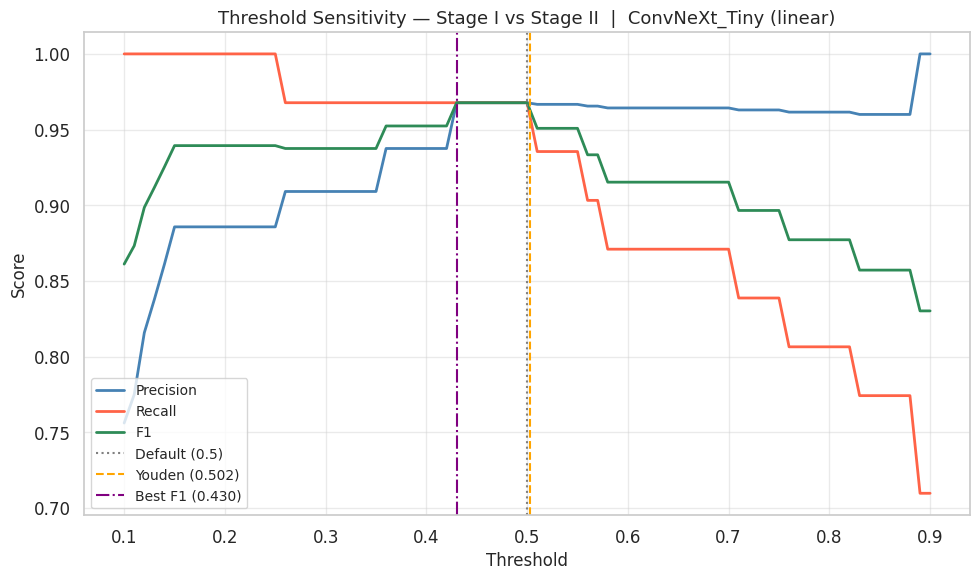

Best-F1 threshold: 0.43  F1=0.9677


In [16]:
thresh_range = np.linspace(0.1, 0.9, 81)
precisions, recalls, f1s = [], [], []
for t in thresh_range:
    pt = (pos_probs >= t).astype(int)
    precisions.append(precision_score(binary_labels, pt, zero_division=0))
    recalls.append(recall_score(binary_labels, pt, zero_division=0))
    f1s.append(f1_score(binary_labels, pt, zero_division=0))

best_f1_idx = int(np.argmax(f1s))
best_f1_thresh = float(thresh_range[best_f1_idx])

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresh_range, precisions, label="Precision", lw=2, color="steelblue")
ax.plot(thresh_range, recalls, label="Recall", lw=2, color="tomato")
ax.plot(thresh_range, f1s, label="F1", lw=2, color="seagreen")
ax.axvline(BINARY_THRESHOLD, color="grey", ls=":", lw=1.5, label=f"Default ({BINARY_THRESHOLD})")
ax.axvline(youden_thresh, color="orange", ls="--", lw=1.5, label=f"Youden ({youden_thresh:.3f})")
ax.axvline(best_f1_thresh, color="purple", ls="-.", lw=1.5, label=f"Best F1 ({best_f1_thresh:.3f})")
ax.set_xlabel("Threshold", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(f"Threshold Sensitivity — Stage I vs Stage II  |  {MODEL_NAME} ({HEAD_TYPE})",
             fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/threshold_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Best-F1 threshold: {best_f1_thresh:.2f}  F1={f1s[best_f1_idx]:.4f}")

## 12. Model Export & Summary

In [18]:
final_path = (
    f"{OUTPUT_DIR}/final_{MODEL_NAME}_{HEAD_TYPE}_{OPTIMIZER_NAME}_{SCHEDULER_NAME}.pth"
)
torch.save(accelerator.unwrap_model(model).state_dict(), final_path)

print("=" * 60)
print("TRAINING & EVALUATION SUMMARY — Stage I vs Stage II")
print("=" * 60)
print(f"Model : {MODEL_NAME}")
print(f"Head : {HEAD_TYPE}  |  Dropout: {DROPOUT}")
print(f"Margin head : {IS_MARGIN_HEAD}"
      + (f"(scale={SCALE}, margin={MARGIN})" if IS_MARGIN_HEAD else ""))
print(f"Optimizer : {OPTIMIZER_NAME} | LR={LR:.2e} | WD={WEIGHT_DECAY:.2e}")
print(f"Scheduler : {SCHEDULER_NAME}")
print(f"img_size : {IMG_SIZE}")
print(f"Epochs run : {len(history['train_loss'])} / {NUM_EPOCHS}")
print(f"Best epoch : {best_epoch} (val_loss={min(history['val_loss']):.4f})")
print(f"Early stop patience: {ES_PATIENCE}")
print()
print(f"Test set size : {len(all_labels_test)}")
print(f"Threshold used : {BINARY_THRESHOLD}")
print()
print(f"Accuracy : {accuracy_score(all_labels_test, all_preds_test):.4f}")
print(f"Macro F1 : {f1_score(all_labels_test, all_preds_test, average='macro'):.4f}")
print(f"Weighted F1 : {f1_score(all_labels_test, all_preds_test, average='weighted'):.4f}")
print(f"AUC-ROC : {auc_val:.4f}")
print(f"Youden threshold : {youden_thresh:.4f}")
print(f"Best-F1 threshold : {best_f1_thresh:.4f}")
print()
print("Saved artefacts:")
for fname in [
    "class_distribution.png", "training_curves.png",
    "confusion_matrices.png",  "roc_curve.png",
    "threshold_sensitivity.png", "sample_predictions.png",
    "metrics_summary.csv",
    Path(BEST_WEIGHTS_PATH).name,
    Path(final_path).name,
]:
    p = Path(OUTPUT_DIR) / fname
    print(f"{'✅' if p.exists() else '❌'}  {fname}")

TRAINING & EVALUATION SUMMARY — Stage I vs Stage II
Model : ConvNeXt_Tiny
Head : linear  |  Dropout: 0.160100050336993
Margin head : False
Optimizer : Lion | LR=1.29e-04 | WD=1.06e-05
Scheduler : CosineAnnealingLR
img_size : 224
Epochs run : 13 / 50
Best epoch : 3 (val_loss=0.2296)
Early stop patience: 10

Test set size : 63
Threshold used : 0.5

Accuracy : 0.9683
Macro F1 : 0.9682
Weighted F1 : 0.9683
AUC-ROC : 0.9909
Youden threshold : 0.5025
Best-F1 threshold : 0.4300

Saved artefacts:
✅  class_distribution.png
✅  training_curves.png
✅  confusion_matrices.png
✅  roc_curve.png
✅  threshold_sensitivity.png
✅  sample_predictions.png
✅  metrics_summary.csv
✅  best_ConvNeXt_Tiny_linear_Lion_CosineAnnealingLR.pth
✅  final_ConvNeXt_Tiny_linear_Lion_CosineAnnealingLR.pth
